<a href="https://colab.research.google.com/github/UDAYNANNAKA/House-Price-Predication/blob/main/house_price_predication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


In [ ]:
data = {
    "size_sqft": [800, 1000, 1200, 1500, 1800, 2000, 2200, 2400,
                  2600, 2800, 3000, 3200, 3500, 3800, 4000, 4500],
    "bedrooms": [2, 2, 2, 3, 3, 3, 3, 4, 4, 4,
                 4, 4, 5, 5, 5, 5],
    "price_lakhs": [40, 48, 55, 65, 75, 82, 90, 100,
                    108, 118, 125, 135, 150, 165, 180, 200]
}

df = pd.DataFrame(data)
print(df)


    size_sqft  bedrooms  price_lakhs
0         800         2           40
1        1000         2           48
2        1200         2           55
3        1500         3           65
4        1800         3           75
5        2000         3           82
6        2200         3           90
7        2400         4          100
8        2600         4          108
9        2800         4          118
10       3000         4          125
11       3200         4          135
12       3500         5          150
13       3800         5          165
14       4000         5          180
15       4500         5          200


In [ ]:
print("Dataset shape:", df.shape)
print("\nFirst five rows:")
print(df.head())

print("\nDataset information:")
print(df.info())

Dataset shape: (16, 3)

First five rows:
   size_sqft  bedrooms  price_lakhs
0        800         2           40
1       1000         2           48
2       1200         2           55
3       1500         3           65
4       1800         3           75

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   size_sqft    16 non-null     int64
 1   bedrooms     16 non-null     int64
 2   price_lakhs  16 non-null     int64
dtypes: int64(3)
memory usage: 516.0 bytes
None


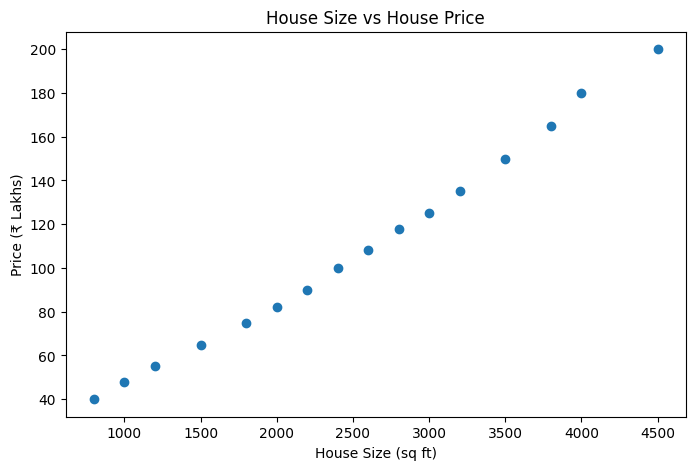

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["size_sqft"], df["price_lakhs"])
plt.xlabel("House Size (sq ft)")
plt.ylabel("Price (₹ Lakhs)")
plt.title("House Size vs House Price")
plt.show()


In [ ]:
X = df[["size_sqft", "bedrooms"]]
y = df["price_lakhs"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())


Features:
   size_sqft  bedrooms
0        800         2
1       1000         2
2       1200         2
3       1500         3
4       1800         3

Target:
0    40
1    48
2    55
3    65
4    75
Name: price_lakhs, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 12
Testing samples: 4


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")


Model trained successfully!


In [ ]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [ 0.04706726 -3.36310386]
Intercept: 0.9180597604316887


In [ ]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(results)

   Actual Price  Predicted Price
0            40        31.845663
1            48        41.259115
2            82        84.963275
3           180       172.371594


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 3))


Mean Absolute Error (MAE): 6.37
Root Mean Squared Error (RMSE): 6.69
R² Score: 0.986


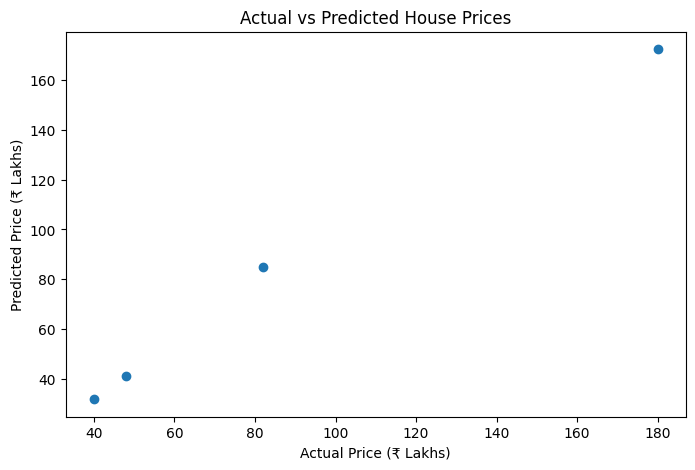

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price (₹ Lakhs)")
plt.ylabel("Predicted Price (₹ Lakhs)")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [ ]:
new_house = pd.DataFrame({
    "size_sqft": [2500],
    "bedrooms": [4]
})

predicted_price = model.predict(new_house)

print(
    "Predicted price for a 2500 sq ft, 4-bedroom house:",
    round(predicted_price[0], 2),
    "lakhs"
)


Predicted price for a 2500 sq ft, 4-bedroom house: 105.13 lakhs
